In [123]:
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sys.path.append(r"D:/Football Project/src")

import feature_lists_3yr as fl

In [124]:
df=pd.read_csv("../../../data/processed/3_year/EWMA_Top5_Leagues.csv")

In [125]:
df=df[df["position"] == "Defenders"].copy()

In [126]:
df=df[df['minutesplayed'] > 540]

In [127]:
df=df.drop(columns=fl.goalkeeper_features)

In [128]:
df.columns.to_list()

['player id',
 'player',
 'team',
 'team id',
 'league',
 'position',
 'number_of_seasons',
 'appearances',
 'accuratechippedpasses',
 'accuratecrosses',
 'accuratefinalthirdpasses',
 'accuratelongballs',
 'accurateoppositionhalfpasses',
 'accurateownhalfpasses',
 'accuratepasses',
 'aerialduelswon',
 'aeriallost',
 'assists',
 'ballrecovery',
 'bigchancescreated',
 'bigchancesmissed',
 'blockedshots',
 'clearances',
 'directredcards',
 'dispossessed',
 'dribbledpast',
 'duellost',
 'errorleadtogoal',
 'errorleadtoshot',
 'expectedassists',
 'expectedgoals',
 'fouls',
 'freekickgoal',
 'goals',
 'goalsassistssum',
 'goalsfrominsidethebox',
 'goalsfromoutsidethebox',
 'groundduelswon',
 'headedgoals',
 'hitwoodwork',
 'inaccuratepasses',
 'interceptions',
 'keypasses',
 'leftfootgoals',
 'matchesstarted',
 'minutesplayed',
 'offsides',
 'owngoals',
 'passtoassist',
 'penaltiestaken',
 'penaltygoals',
 'possessionlost',
 'possessionwonattthird',
 'redcards',
 'rightfootgoals',
 'shotfrom

In [129]:
volumes_drop = [
    'accuratechippedpasses', 'accuratecrosses', 'accuratefinalthirdpasses', 
    'accuratelongballs', 'accurateoppositionhalfpasses', 'accurateownhalfpasses', 
    'accuratepasses', 'aerialduelswon', 'aeriallost', 'assists', 'ballrecovery', 
    'bigchancescreated', 'bigchancesmissed', 'blockedshots', 'clearances', 
    'directredcards', 'dispossessed', 'dribbledpast', 'duellost', 'errorleadtogoal', 
    'errorleadtoshot', 'expectedassists', 'expectedgoals', 'fouls', 'freekickgoal', 
    'goals', 'goalsassistssum', 'goalsfrominsidethebox', 'goalsfromoutsidethebox', 
    'groundduelswon', 'headedgoals', 'hitwoodwork', 'inaccuratepasses', 
    'interceptions', 'keypasses', 'leftfootgoals', 'offsides', 'owngoals', 
    'passtoassist', 'penaltiestaken', 'penaltygoals', 'possessionlost', 
    'possessionwonattthird', 'redcards', 'rightfootgoals', 'shotfromsetpiece', 
    'shotsfrominsidethebox', 'shotsfromoutsidethebox', 'shotsofftarget', 
    'shotsontarget', 'successfuldribbles', 'tackles', 'tackleswon', 
    'totalattemptassist', 'totalchippedpasses', 'totalcontest', 'totalcross', 
    'totalduelswon', 'totallongballs', 'totaloppositionhalfpasses', 
    'totalownhalfpasses', 'totalpasses', 'totalshots', 'totwappearances', 
    'touches', 'wasfouled', 'yellowcards', 'yellowredcards', 'defensive_actions',
    'assists_minus_xa','goals_minus_xg'
]

df=df.drop(columns=volumes_drop)

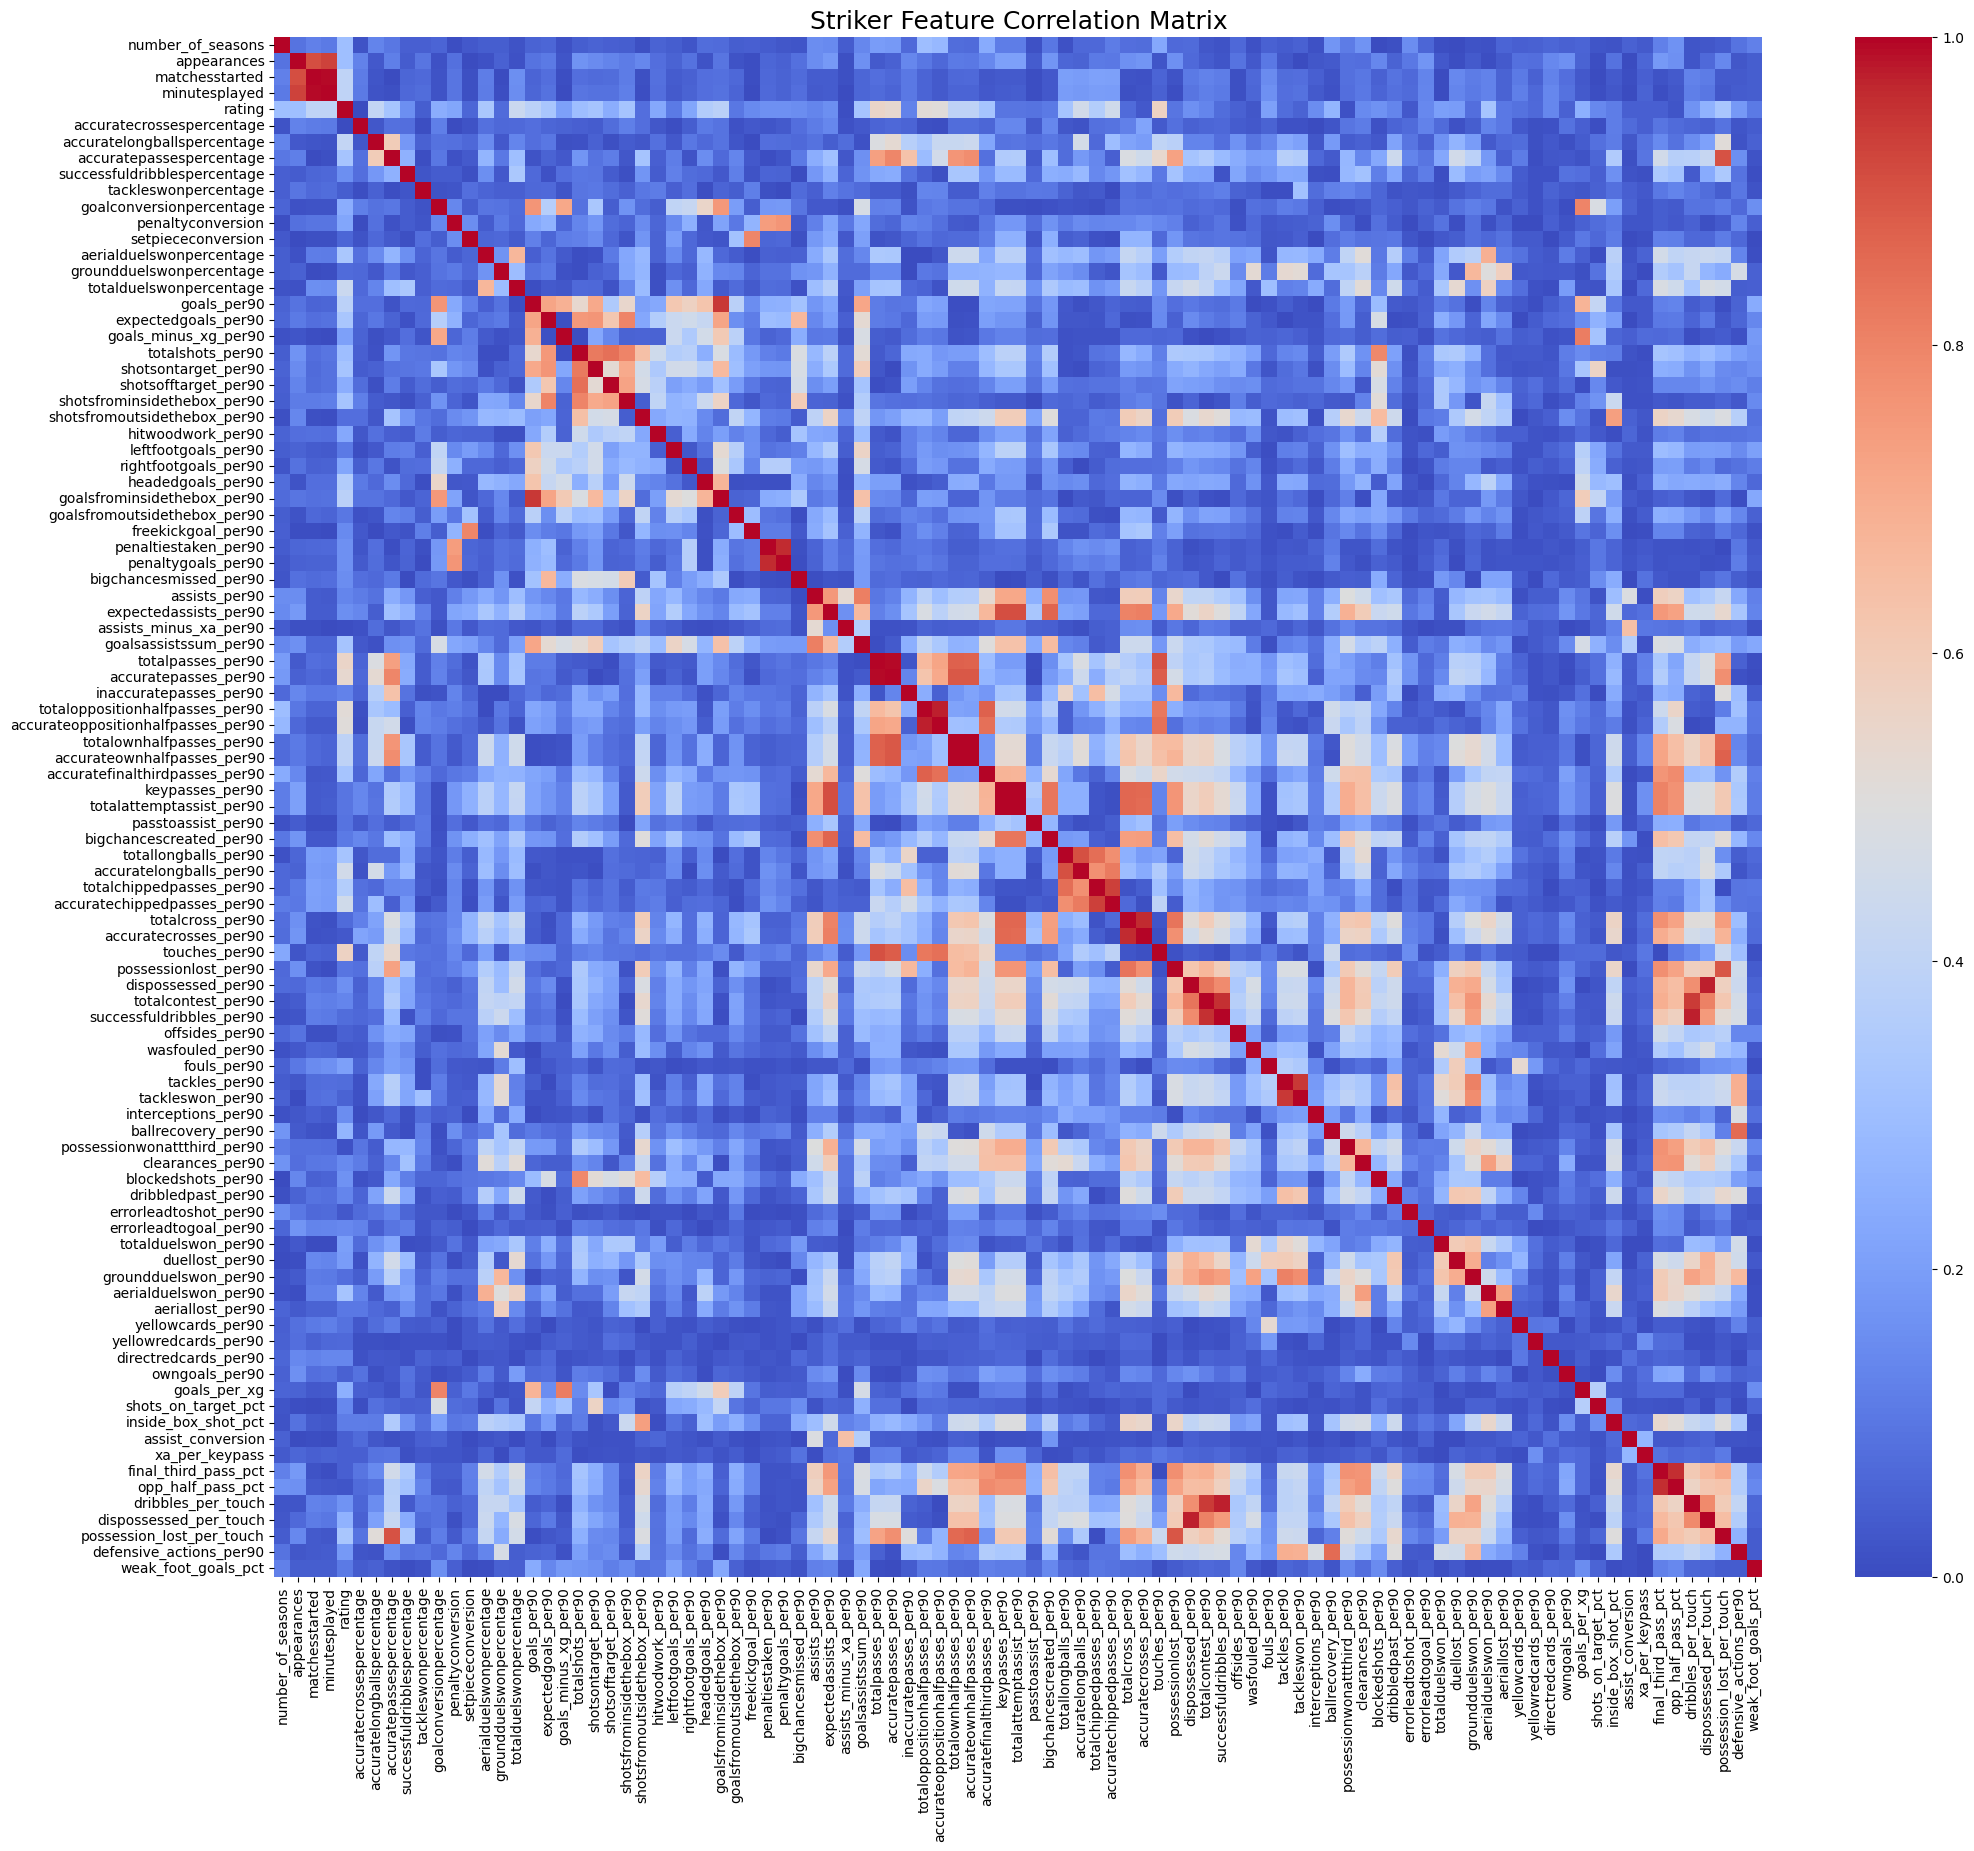

In [130]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [131]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,keypasses_per90,totalattemptassist_per90,0.999531
1,totalownhalfpasses_per90,accurateownhalfpasses_per90,0.998586
2,matchesstarted,minutesplayed,0.994015
3,totalpasses_per90,accuratepasses_per90,0.993392
4,totaloppositionhalfpasses_per90,accurateoppositionhalfpasses_per90,0.976021
5,successfuldribbles_per90,dribbles_per_touch,0.974473
6,dispossessed_per90,dispossessed_per_touch,0.973053
7,penaltiestaken_per90,penaltygoals_per90,0.961940
8,totalcross_per90,accuratecrosses_per90,0.961094
9,final_third_pass_pct,opp_half_pass_pct,0.959748


In [132]:
drops = [
    'matchesstarted','appearances','totalpasses_per90', 'totalownhalfpasses_per90', 'totaloppositionhalfpasses_per90',
    'totalcross_per90', 'totallongballs_per90', 'totalchippedpasses_per90',
    'successfuldribbles_per90', 'dispossessed_per90', 'totalcontest_per90',
    'totalattemptassist_per90', 'keypasses_per90', 'tackles_per90', 'ballrecovery_per90',
    'goalsfrominsidethebox_per90', 'penaltygoals_per90','touches_per90',
    'accurateownhalfpasses_per90','bigchancescreated_per90','opp_half_pass_pct',
    'accuratechippedpasses_per90','accurateoppositionhalfpasses_per90','freekickgoal_per90',
    'possessionlost_per90','accuratepassespercentage','directredcards_per90','yellowredcards_per90',
    'totalshots_per90','goalsassistssum_per90','goalconversionpercentage','goals_minus_xg_per90'
    
]
df=df.drop(columns=drops)

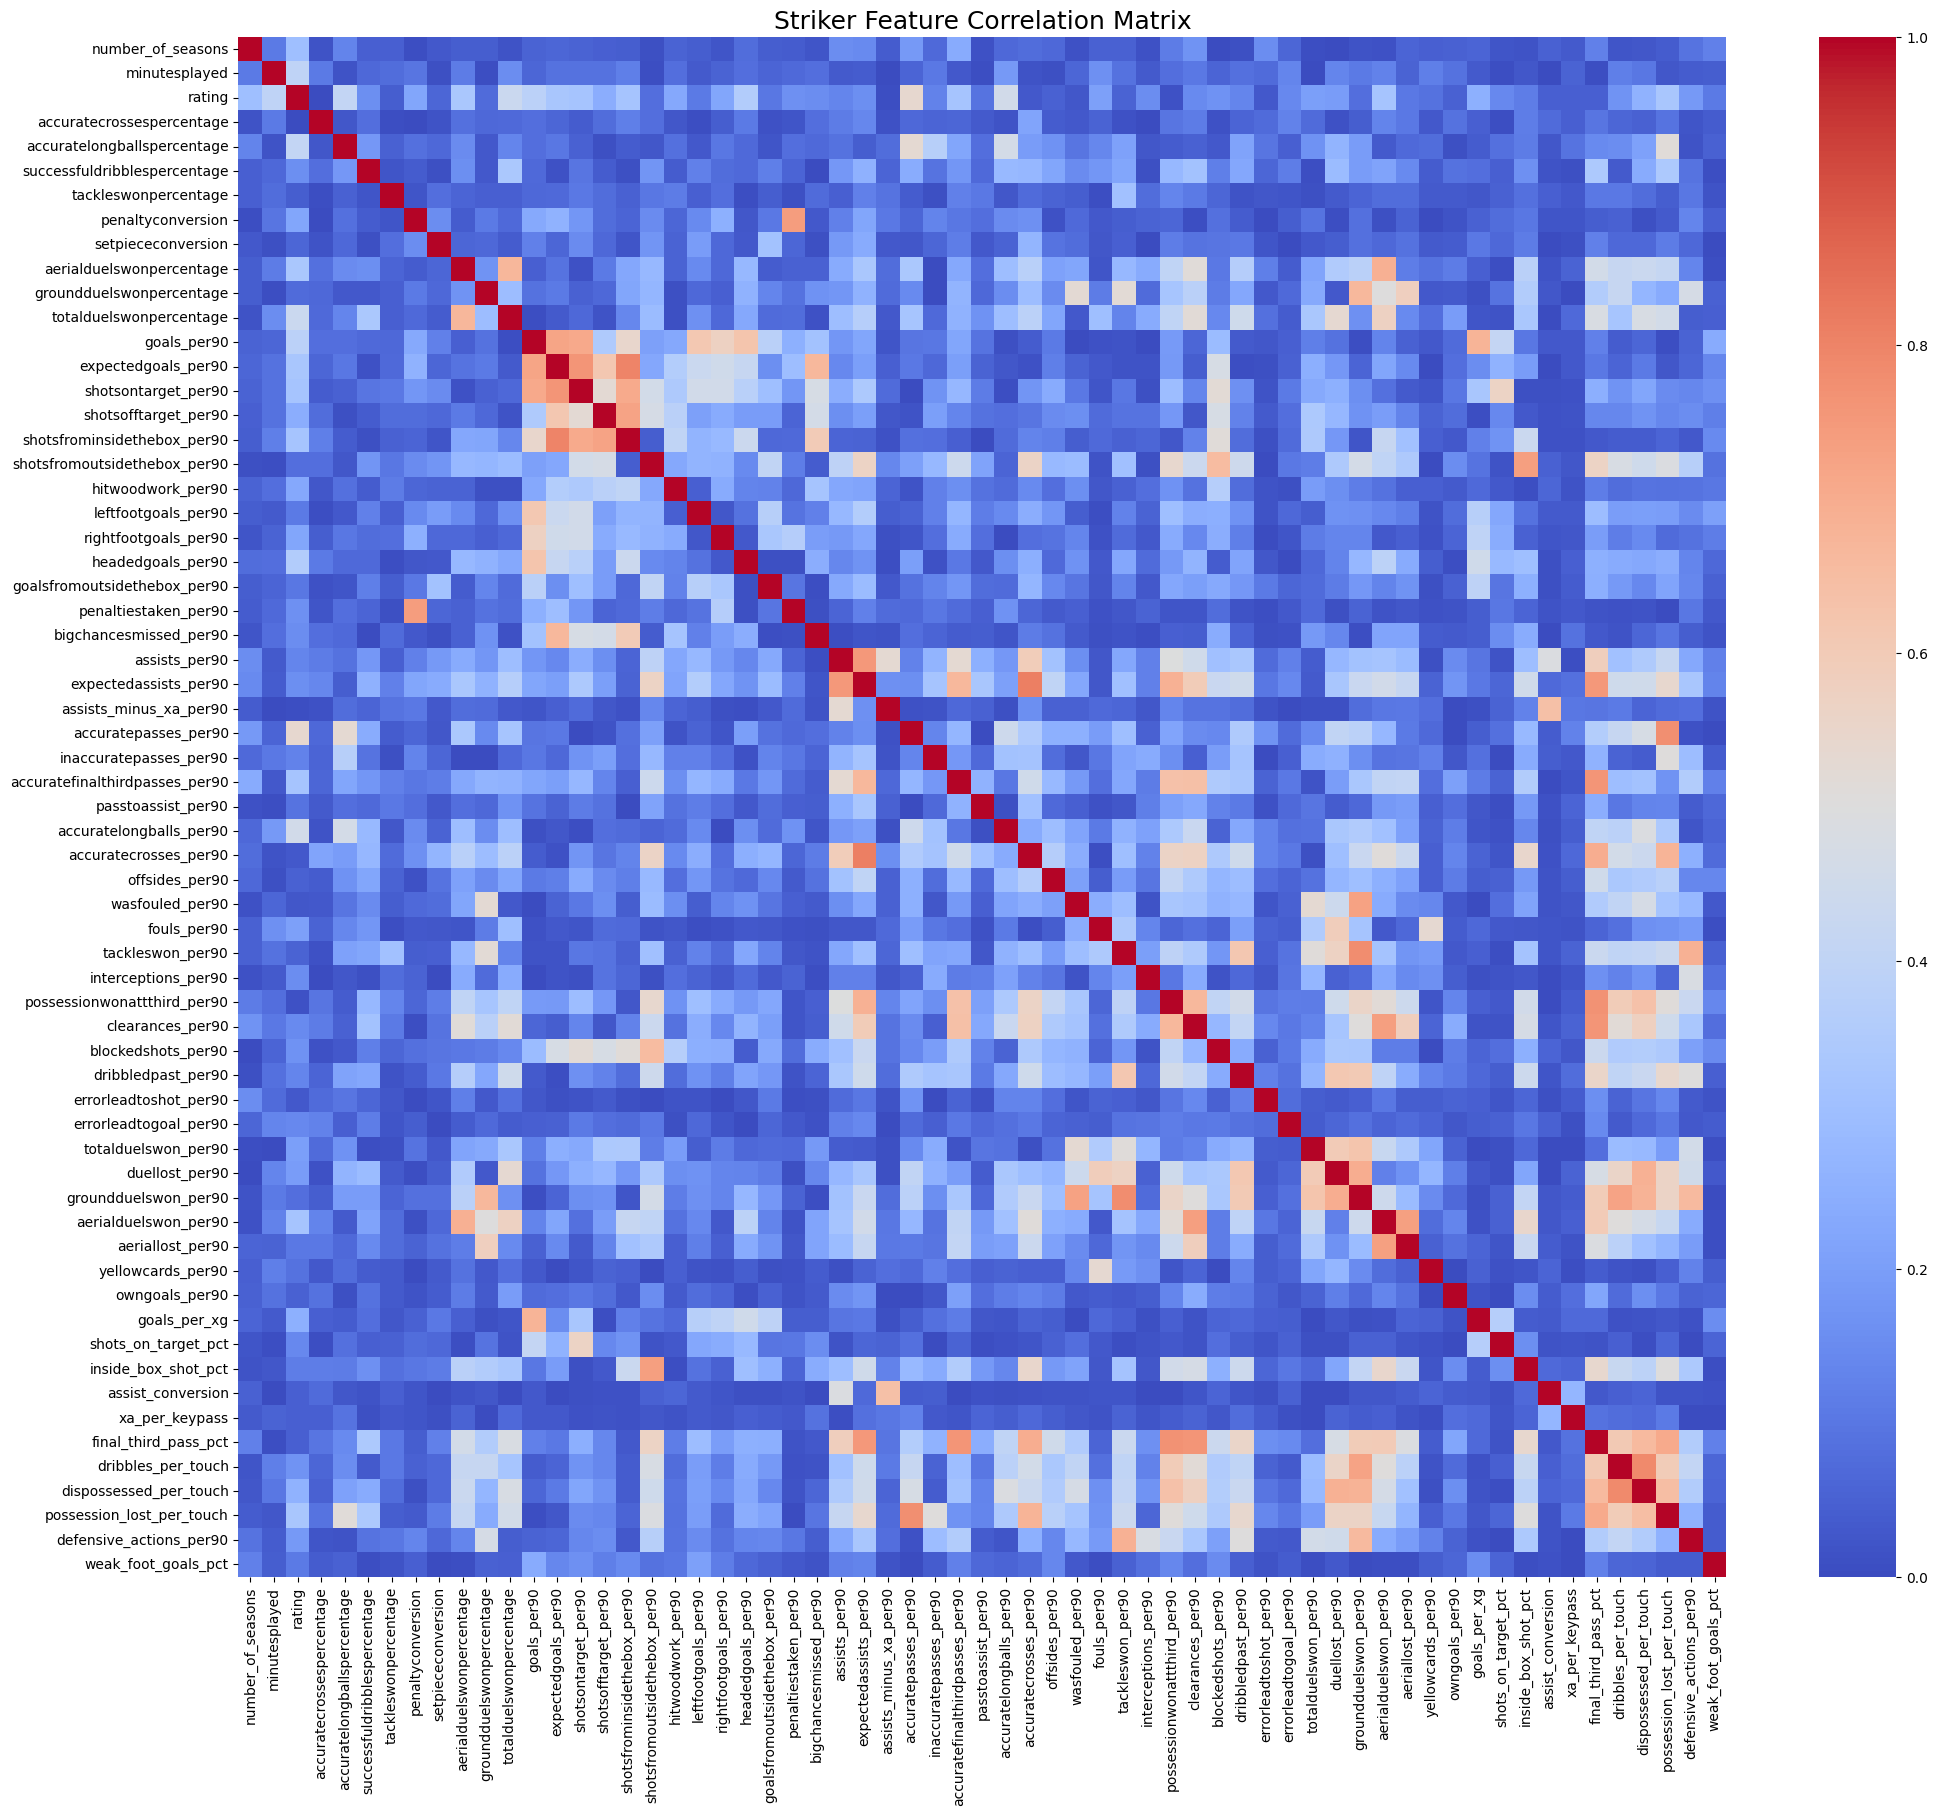

In [133]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [134]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,expectedassists_per90,accuratecrosses_per90,0.810298


In [135]:
df.shape

(690, 69)

In [136]:
df.select_dtypes(include=['number']).isna().sum().sum()

np.int64(306)

In [137]:
df.info()

<class 'pandas.DataFrame'>
Index: 690 entries, 2 to 2654
Data columns (total 69 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   player id                       690 non-null    int64  
 1   player                          690 non-null    str    
 2   team                            690 non-null    str    
 3   team id                         690 non-null    int64  
 4   league                          690 non-null    str    
 5   position                        690 non-null    str    
 6   number_of_seasons               690 non-null    int64  
 7   minutesplayed                   690 non-null    float64
 8   rating                          690 non-null    float64
 9   accuratecrossespercentage       690 non-null    float64
 10  accuratelongballspercentage     690 non-null    float64
 11  successfuldribblespercentage    690 non-null    float64
 12  tackleswonpercentage            690 non-null    flo

In [138]:
df=df.fillna(0)

In [139]:
df.to_csv('../../../data/processed/3_year/Defenders/EWMA_Top5_Defenders.csv',index=False)